# Aurelia's Code

Referenced from [Julia's Code](https://colab.research.google.com/drive/1rz2T15TX-UB0n8zLH3tPMvakw33zQBx6?usp=sharing)

R² Score: 0.1037
Mean Absolute Error: 4465515.52
Root Mean Squared Error: 11571992.63


<ipython-input-9-57a75714e516>:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df.head(15), x='Coefficient', y='Feature', palette='viridis')


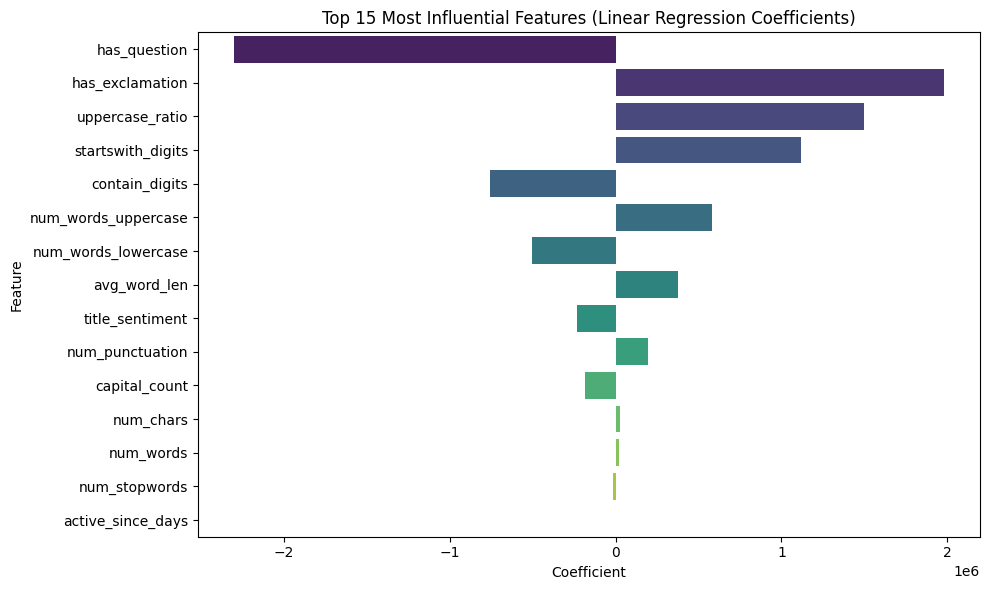

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('cleaned_dataset.csv')

# Target for regression
y = df['total_views']

# Drop columns we shouldn't use as predictors
drop_cols = [
    'title_original', 'title_clean', 'title_tokens', 'title_lemmas',
    'total_views', 'view_category_quantile', 'view_category_3bin'
]
X = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

# Feature importances (coefficients)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', key=lambda x: x.abs(), ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(15), x='Coefficient', y='Feature', palette='viridis')
plt.title('Top 15 Most Influential Features (Linear Regression Coefficients)')
plt.tight_layout()
plt.show()
